# SPY Drawdown Regimes, VIX Pace, Credit Pace, and Sector Spillover

**Goal.** Test three concrete ideas without forward-looking bias:
1. Drawdowns that start from stronger markets should be shallower or recover faster than drawdowns that begin from weaker backdrops.
2. Faster changes in VIX and credit conditions should help explain whether a drawdown becomes a quick shock or a deeper, slower unwind.
3. Sector ETFs that are already stretched versus SPY should react differently during SPY drawdown windows, especially in ratio terms.

This notebook is a Kaggle-style walkthrough of the research outputs generated by `spy_drawdown_regime_research.py`.

## 1. Load the research outputs

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.4f}'.format

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESEARCH_DIR = PROJECT_ROOT / 'outputs' / 'spy_drawdown_regime_research'
print('research dir:', RESEARCH_DIR)

research dir: D:\dev\price_action\outputs\spy_drawdown_regime_research


In [2]:
with open(RESEARCH_DIR / 'spy_drawdown_regime_summary.json', encoding='utf-8') as f:
    summary = json.load(f)

panel = pd.read_csv(RESEARCH_DIR / 'drawdown_daily_panel.csv', parse_dates=['signal_date', 'entry_date'])
episodes = pd.read_csv(RESEARCH_DIR / 'spy_drawdown_episodes.csv', parse_dates=['peak_date', 'onset_date', 'trough_date', 'recovery_date'])
strength_summary = pd.read_csv(RESEARCH_DIR / 'drawdown_strength_summary.csv')
combined_summary = pd.read_csv(RESEARCH_DIR / 'drawdown_combined_regime_summary.csv')
hypothesis_summary = pd.read_csv(RESEARCH_DIR / 'hypothesis_test_summary.csv')
pace_summary = pd.read_csv(RESEARCH_DIR / 'pace_factor_summary.csv')
sector_regime = pd.read_csv(RESEARCH_DIR / 'sector_regime_ratio_summary.csv')
sector_stretch = pd.read_csv(RESEARCH_DIR / 'sector_stretch_summary.csv')
sector_stretch_effect = pd.read_csv(RESEARCH_DIR / 'sector_stretch_effect_summary.csv')
sector_episode = pd.read_csv(RESEARCH_DIR / 'sector_drawdown_episode_ratios.csv', parse_dates=['peak_date', 'onset_date', 'trough_date', 'recovery_date'])

headline = pd.DataFrame({
    'metric': ['panel rows', 'episodes', 'drawdown threshold', 'lookback window', 'sector observations'],
    'value': [summary['rows'], summary['episode_count'], summary['drawdown_threshold'], summary['lookback_window'], len(sector_episode)],
})
display(headline)

,metric,value
0,panel rows,"6,607.0000"
1,episodes,24.0000
2,drawdown threshold,-0.0500
3,lookback window,252.0000
4,sector observations,242.0000


## 2. Research guardrails

The study is descriptive, but the state labels are still point-in-time.
1. Market strength and fragility are measured using only trailing information available on the peak or onset date.
2. Drawdown depth, speed, and recovery are evaluated after the episode ends, but no forward data leaks into the regime labels.
3. Sector stretch is measured from the sector-to-SPY ratio at drawdown onset, not from future relative performance.

## 3. Does a stronger starting market change the drawdown profile?

,pre_drawdown_market_strength_regime,episode_count,avg_max_drawdown,median_max_drawdown,avg_peak_to_trough_days,avg_drawdown_speed,avg_trough_to_20d_return,avg_trough_to_60d_return,recovered_within_20d_rate,recovered_within_60d_rate,avg_trough_to_recovery_days
0,Neutral,4,-0.0828,-0.0748,47.7500,0.0036,0.0826,0.1225,0.5000,1.0000,25.0000
1,Strong,12,-0.0993,-0.0632,22.0833,0.0057,0.0801,0.1254,0.4167,0.7500,42.8333
2,Unclassified,2,-0.2756,-0.2756,324.5000,0.0035,0.1730,0.1246,0.5000,0.5000,517.0000
3,Weak,6,-0.2061,-0.1390,111.0000,0.0031,0.1156,0.1741,0.3333,0.6667,212.3333


,hypothesis,left_group,right_group,metric,left_value,right_value,supports_hypothesis
0,Weak-market drawdowns are deeper than strong-m...,Weak,Strong,abs(max_drawdown),0.2061,0.0993,True
1,Weak-market drawdowns unfold faster than stron...,Weak,Strong,drawdown_speed_from_peak_per_day,0.0031,0.0057,False
2,Weak-market drawdowns recover more slowly than...,Weak,Strong,recovered_within_60d_rate,0.6667,0.7500,True


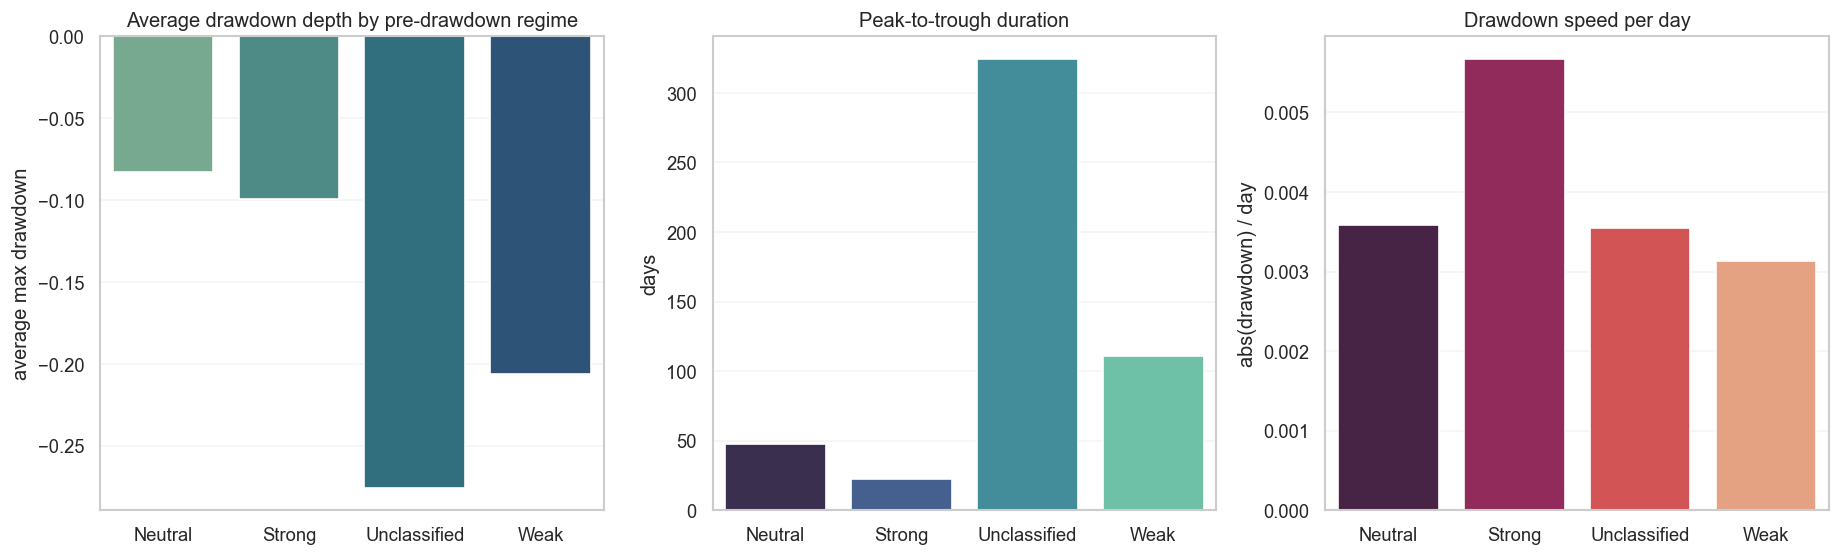

In [3]:
display(strength_summary.round(4))
display(hypothesis_summary)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
sns.barplot(data=strength_summary, x='pre_drawdown_market_strength_regime', y='avg_max_drawdown', hue='pre_drawdown_market_strength_regime', dodge=False, legend=False, palette='crest', ax=axes[0])
axes[0].set_title('Average drawdown depth by pre-drawdown regime')
axes[0].set_xlabel('')
axes[0].set_ylabel('average max drawdown')

sns.barplot(data=strength_summary, x='pre_drawdown_market_strength_regime', y='avg_peak_to_trough_days', hue='pre_drawdown_market_strength_regime', dodge=False, legend=False, palette='mako', ax=axes[1])
axes[1].set_title('Peak-to-trough duration')
axes[1].set_xlabel('')
axes[1].set_ylabel('days')

sns.barplot(data=strength_summary, x='pre_drawdown_market_strength_regime', y='avg_drawdown_speed', hue='pre_drawdown_market_strength_regime', dodge=False, legend=False, palette='rocket', ax=axes[2])
axes[2].set_title('Drawdown speed per day')
axes[2].set_xlabel('')
axes[2].set_ylabel('abs(drawdown) / day')
plt.tight_layout()
plt.show()

**Interpretation.**

The output usually splits the question into two different mechanisms: depth versus speed. Weak-market drawdowns can be materially deeper and take longer to fully repair, while strong-market drawdowns can still happen fast because shock repricing is sharp when positioning is crowded.

## 4. Add the fragility tier: calm, fragile, or stress

,pre_drawdown_market_strength_regime,pre_drawdown_combined_regime,episode_count,avg_max_drawdown,avg_peak_to_trough_days,avg_drawdown_speed,avg_trough_to_20d_return,avg_trough_to_60d_return,recovered_within_60d_rate
0,Neutral,Neutral / Calm,2,-0.0907,82.0000,0.0017,0.0910,0.1248,1.0000
1,Neutral,Neutral / Fragile,2,-0.0748,13.5000,0.0055,0.0741,0.1202,1.0000
2,Strong,Strong / Calm,12,-0.0993,22.0833,0.0057,0.0801,0.1254,0.7500
3,Unclassified,Unclassified / Calm,1,-0.4752,637.0000,0.0007,0.1913,0.1961,0.0000
4,Unclassified,Unclassified / Fragile,1,-0.0761,12.0000,0.0063,0.1547,0.0532,1.0000
5,Weak,Weak / Calm,2,-0.1382,38.5000,0.0038,0.1282,0.2539,1.0000
6,Weak,Weak / Fragile,2,-0.3123,187.5000,0.0026,0.1662,0.2378,0.5000
7,Weak,Weak / Stress,2,-0.1677,107.0000,0.0030,0.0525,0.0706,0.5000


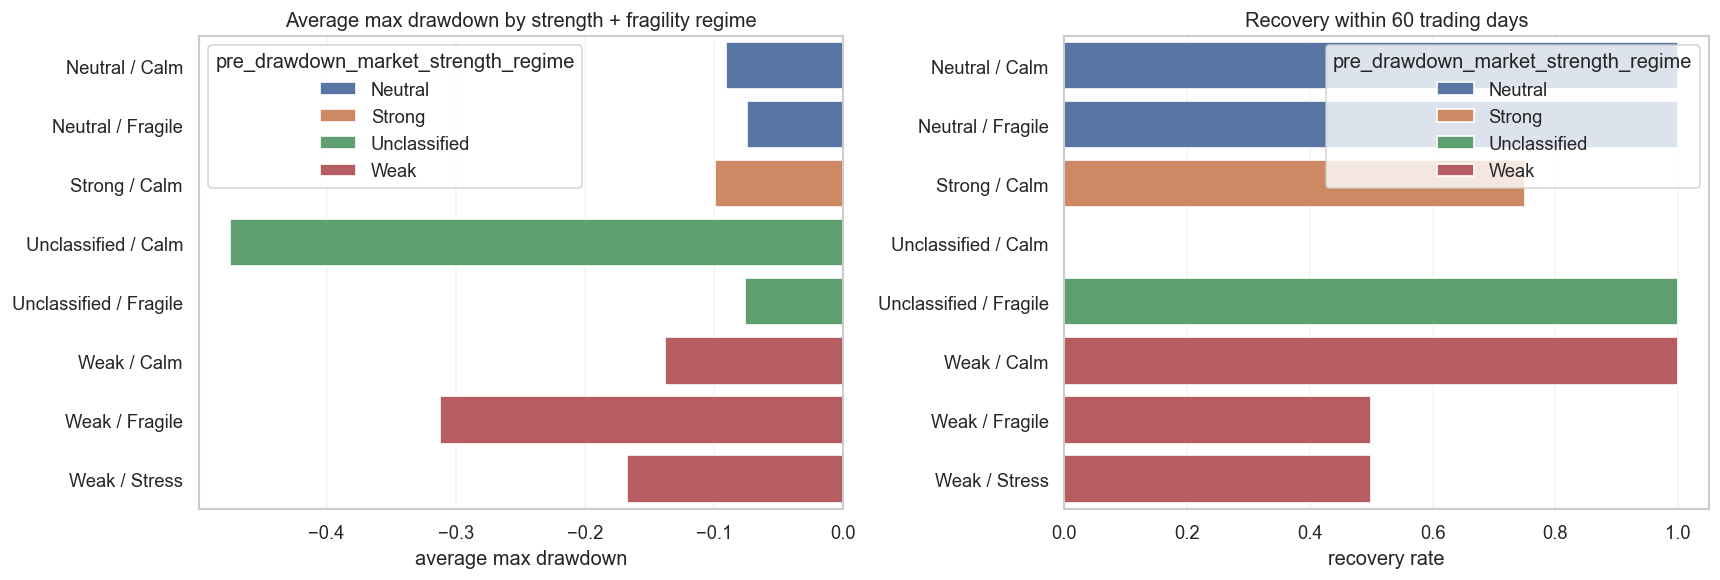

In [4]:
display(combined_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0))
sns.barplot(data=combined_summary, y='pre_drawdown_combined_regime', x='avg_max_drawdown', hue='pre_drawdown_market_strength_regime', ax=axes[0])
axes[0].set_title('Average max drawdown by strength + fragility regime')
axes[0].set_xlabel('average max drawdown')
axes[0].set_ylabel('')

sns.barplot(data=combined_summary, y='pre_drawdown_combined_regime', x='recovered_within_60d_rate', hue='pre_drawdown_market_strength_regime', ax=axes[1])
axes[1].set_title('Recovery within 60 trading days')
axes[1].set_xlabel('recovery rate')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Does VIX pace or credit pace explain what comes next?

,factor,outcome,observations,correlation,high_bucket_mean,low_bucket_mean,high_minus_low
0,credit_pace_score,drawdown_speed_from_peak_per_day,24,0.3746,0.0071,0.0039,0.0033
1,credit_pace_score,max_drawdown_abs,24,0.0897,0.1288,0.1079,0.0209
2,credit_pace_score,recovered_within_60d,24,-0.0873,0.8000,0.8000,0.0000
3,credit_pace_score,trough_to_20d_return,24,0.0533,0.0966,0.0719,0.0247
4,credit_pace_score,trough_to_60d_return,23,0.1938,0.1574,0.0962,0.0612
5,high_yield_spread_change_5d_zscore,drawdown_speed_from_peak_per_day,22,0.3628,0.0071,0.0030,0.0041
6,high_yield_spread_change_5d_zscore,max_drawdown_abs,22,-0.0391,0.1288,0.1105,0.0183
7,high_yield_spread_change_5d_zscore,recovered_within_60d,22,0.0736,0.8000,0.8000,0.0000
8,high_yield_spread_change_5d_zscore,trough_to_20d_return,22,-0.0028,0.0966,0.0662,0.0304
9,high_yield_spread_change_5d_zscore,trough_to_60d_return,21,-0.0171,0.1574,0.1069,0.0504


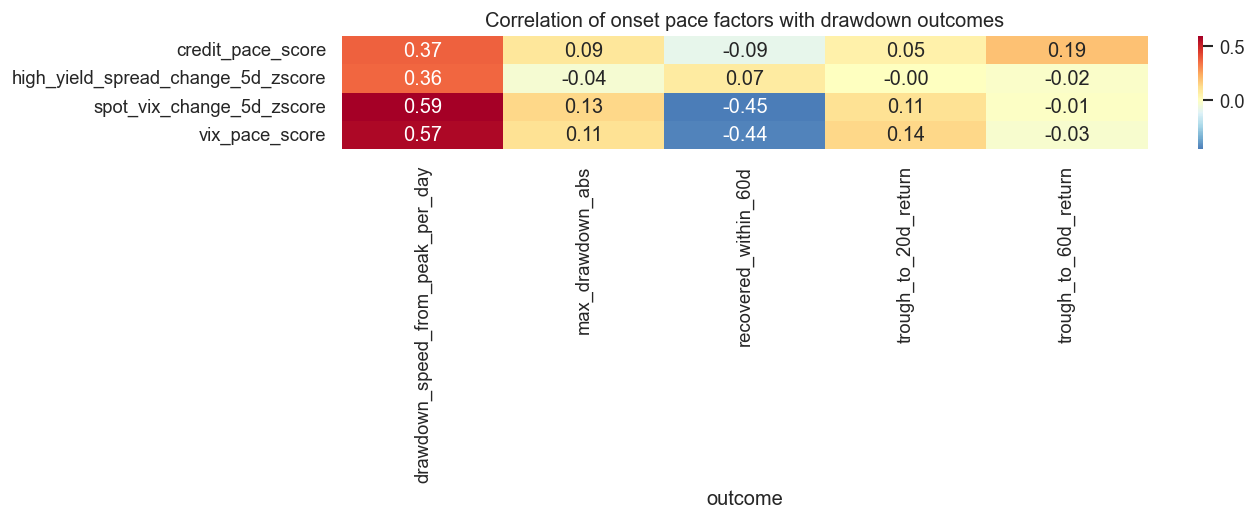

,factor,outcome,high_bucket_mean,low_bucket_mean,high_minus_low
0,credit_pace_score,drawdown_speed_from_peak_per_day,0.0071,0.0039,0.0033
1,credit_pace_score,max_drawdown_abs,0.1288,0.1079,0.0209
2,credit_pace_score,recovered_within_60d,0.8000,0.8000,0.0000
5,high_yield_spread_change_5d_zscore,drawdown_speed_from_peak_per_day,0.0071,0.0030,0.0041
6,high_yield_spread_change_5d_zscore,max_drawdown_abs,0.1288,0.1105,0.0183
7,high_yield_spread_change_5d_zscore,recovered_within_60d,0.8000,0.8000,0.0000
10,spot_vix_change_5d_zscore,drawdown_speed_from_peak_per_day,0.0079,0.0034,0.0044
11,spot_vix_change_5d_zscore,max_drawdown_abs,0.1424,0.0753,0.0671
12,spot_vix_change_5d_zscore,recovered_within_60d,0.6000,1.0000,-0.4000
15,vix_pace_score,drawdown_speed_from_peak_per_day,0.0075,0.0033,0.0043


In [5]:
display(pace_summary.round(4))

heatmap = pace_summary.pivot(index='factor', columns='outcome', values='correlation')
fig, ax = plt.subplots(figsize=(11.5, 4.5))
sns.heatmap(heatmap, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0.0, ax=ax)
ax.set_title('Correlation of onset pace factors with drawdown outcomes')
ax.set_xlabel('outcome')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

bucket_view = pace_summary.loc[pace_summary['outcome'].isin(['max_drawdown_abs', 'drawdown_speed_from_peak_per_day', 'recovered_within_60d'])].copy()
display(bucket_view[['factor', 'outcome', 'high_bucket_mean', 'low_bucket_mean', 'high_minus_low']].round(4))

**Interpretation.**

Higher VIX pace is usually the cleanest warning for a fast break. Credit pace often looks weaker for depth, but it can still matter for persistence and the character of the recovery. In other words, VIX pace tends to explain the *violence* of the move, while credit deterioration helps explain whether the backdrop is structurally sick.

## 6. Sector damage in ratio terms

,sector,pre_drawdown_market_strength_regime,observations,avg_same_date_drawdown_ratio,avg_window_drawdown_ratio,avg_recovery_ratio_vs_spy,avg_relative_return_63d
11,TECHNOLOGY,Strong,12,1.3124,1.3154,1.2782,-0.0074
12,CONSUMER DISCRETIONARY,Strong,12,1.1765,1.1775,1.1544,-0.0047
13,ENERGY,Strong,12,0.9425,1.0164,0.8826,-0.0307
14,FINANCIALS,Strong,12,0.9742,1.0133,0.9090,0.0014
15,INDUSTRIALS,Strong,12,0.9906,0.9984,0.9703,-0.0093
16,MATERIALS,Strong,12,0.9217,0.9613,0.9090,-0.0163
17,COMMUNICATION SERVICES,Strong,7,0.9341,0.9386,0.8873,0.0111
18,CONSUMER STAPLES,Strong,12,0.5757,0.6630,0.6529,-0.0012
19,HEALTHCARE,Strong,12,0.5093,0.6051,0.7691,0.0173
20,REAL ESTATE,Strong,8,0.5051,0.5903,0.8920,-0.0031


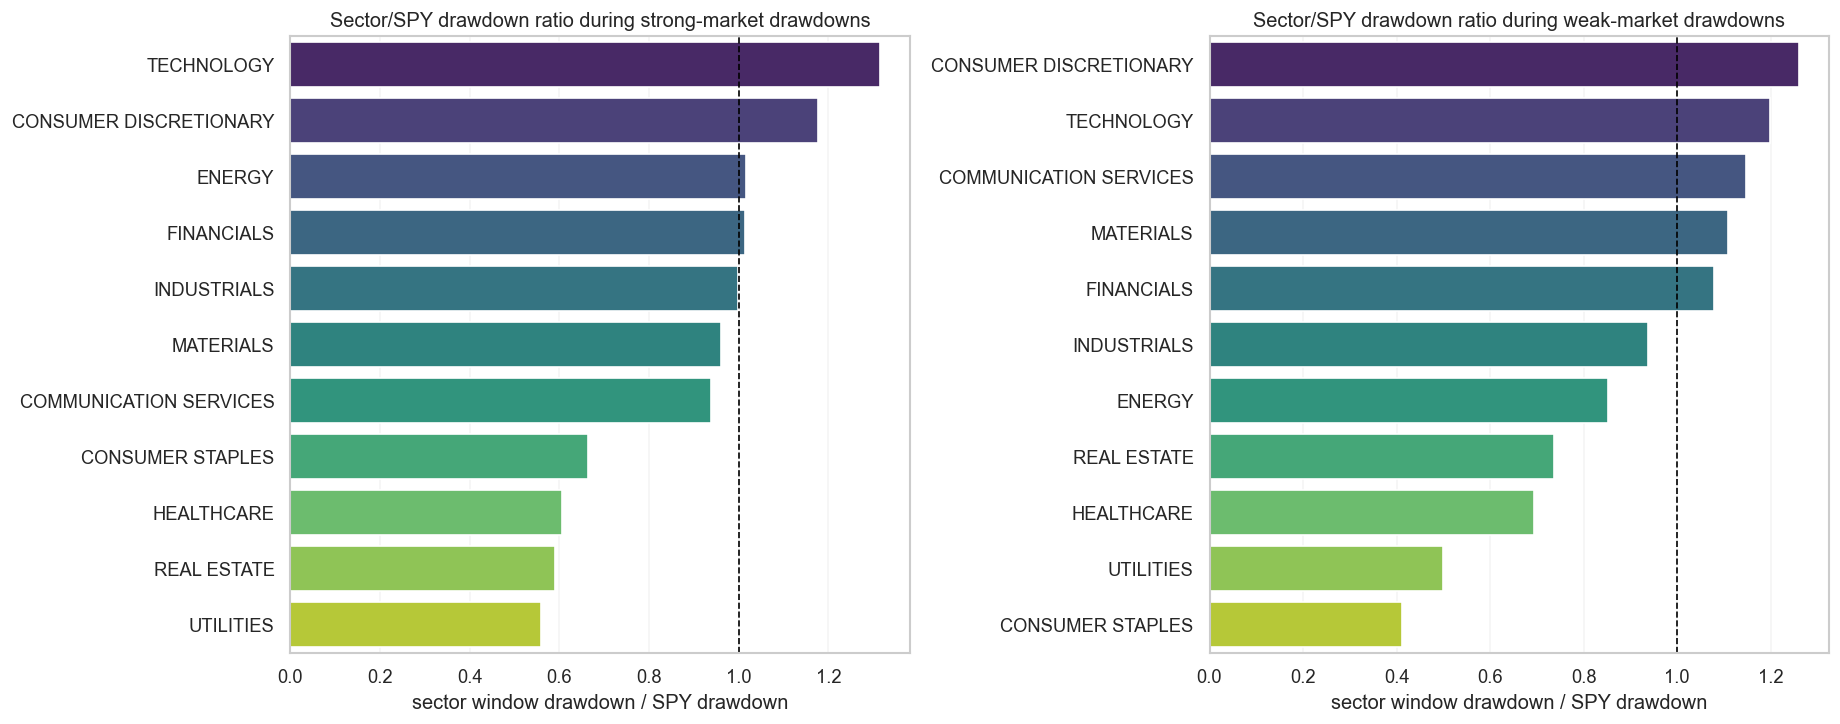

In [6]:
sector_focus = sector_regime.loc[sector_regime['pre_drawdown_market_strength_regime'].isin(['Strong', 'Weak'])].copy()
display(sector_focus.round(4))

plot_data = sector_focus.sort_values(['pre_drawdown_market_strength_regime', 'avg_window_drawdown_ratio'], ascending=[True, False])
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2), sharex=False)
for ax, regime in zip(axes, ['Strong', 'Weak']):
    subset = plot_data.loc[plot_data['pre_drawdown_market_strength_regime'] == regime].sort_values('avg_window_drawdown_ratio', ascending=False)
    sns.barplot(data=subset, y='sector', x='avg_window_drawdown_ratio', hue='sector', dodge=False, legend=False, palette='viridis', ax=ax)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.0)
    ax.set_title(f'Sector/SPY drawdown ratio during {regime.lower()}-market drawdowns')
    ax.set_xlabel('sector window drawdown / SPY drawdown')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

A drawdown ratio above **1.0** means the sector lost more than SPY over the same stress window. A ratio below **1.0** means the sector was more defensive than SPY. That is the cleanest way to answer the user question in ratio terms.

## 7. Do stretched sectors get hit differently?

,sector,stretch_bucket,observations,avg_stretch_score,avg_same_date_drawdown_ratio,avg_window_drawdown_ratio,avg_recovery_ratio_vs_spy
0,COMMUNICATION SERVICES,Cheap,2,-1.2565,1.3252,1.3252,1.3391
1,COMMUNICATION SERVICES,Neutral,6,0.2354,0.8679,0.8880,0.6990
2,COMMUNICATION SERVICES,Rich,3,1.3845,1.1646,1.1646,1.0087
3,COMMUNICATION SERVICES,Unknown,1,NaN,1.0249,1.0249,1.0675
4,CONSUMER DISCRETIONARY,Cheap,8,-1.6356,1.3482,1.3482,1.2057
5,CONSUMER DISCRETIONARY,Neutral,9,-0.1247,1.0832,1.0968,1.0101
6,CONSUMER DISCRETIONARY,Rich,5,1.6482,0.8483,0.8568,1.0850
7,CONSUMER DISCRETIONARY,Unknown,2,NaN,1.1355,1.1770,1.2825
8,CONSUMER STAPLES,Cheap,1,-1.5825,1.2662,1.2662,0.7604
9,CONSUMER STAPLES,Neutral,17,0.2115,0.4919,0.5659,0.5796


,sector,observations,stretch_to_drawdown_corr,stretch_to_recovery_corr
0,FINANCIALS,22,-0.2039,-0.2310
1,HEALTHCARE,22,-0.2429,0.0984
2,INDUSTRIALS,22,-0.3052,-0.2775
3,TECHNOLOGY,22,-0.3283,-0.1213
4,MATERIALS,22,-0.3312,0.0729
5,COMMUNICATION SERVICES,11,-0.4054,-0.3427
6,REAL ESTATE,14,-0.4235,-0.2111
7,UTILITIES,22,-0.4646,-0.2352
8,CONSUMER STAPLES,22,-0.4666,0.0183
9,CONSUMER DISCRETIONARY,22,-0.6544,-0.2421


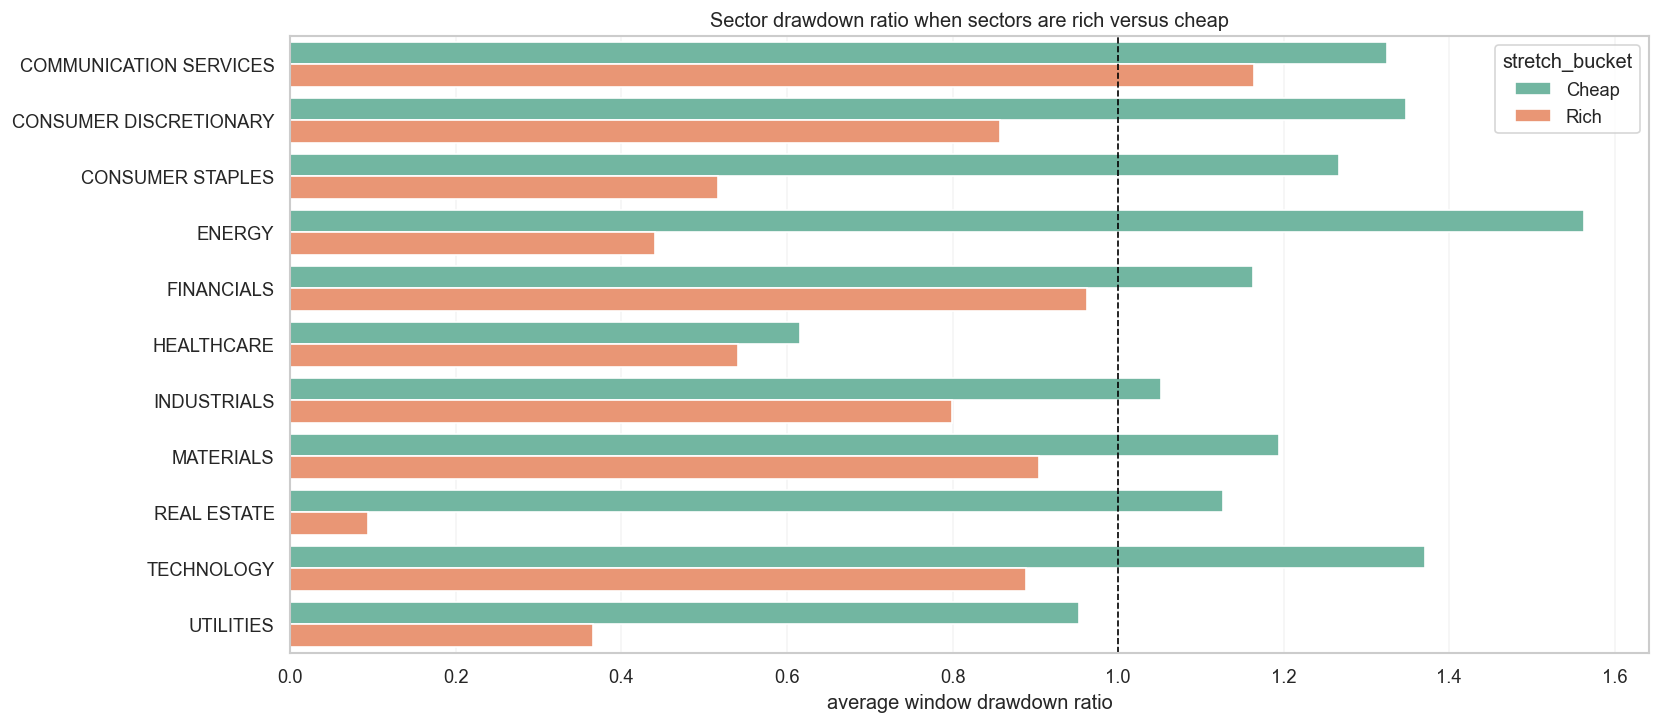

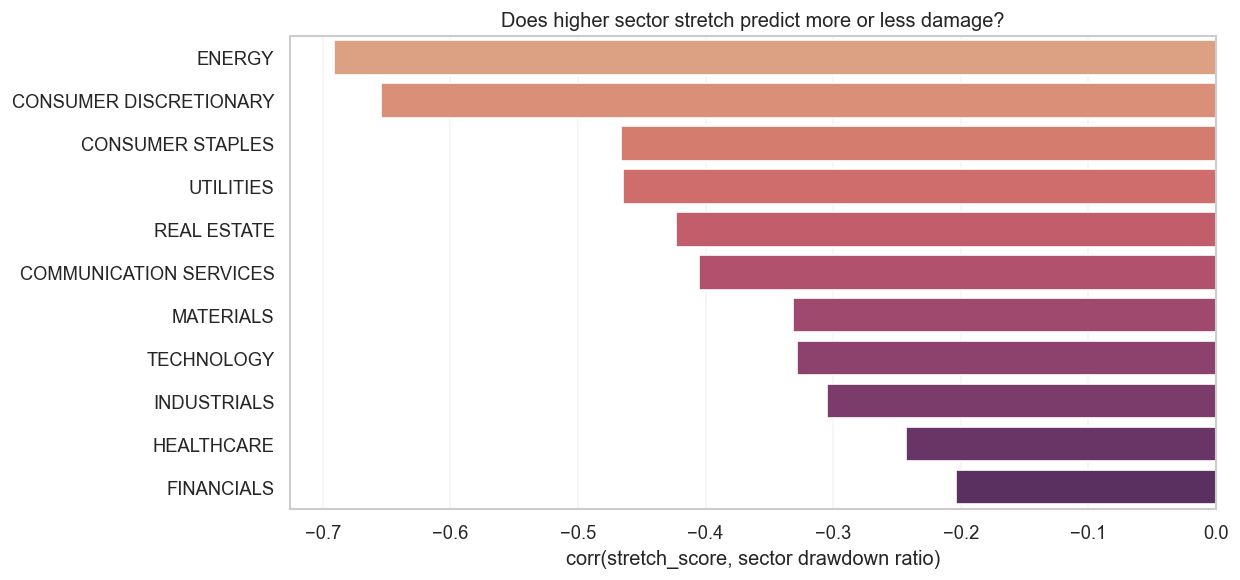

In [7]:
display(sector_stretch.round(4))
display(sector_stretch_effect.round(4))

focus = sector_stretch.loc[sector_stretch['stretch_bucket'].isin(['Rich', 'Cheap'])].copy()
fig, ax = plt.subplots(figsize=(14, 6.2))
sns.barplot(data=focus, y='sector', x='avg_window_drawdown_ratio', hue='stretch_bucket', palette='Set2', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Sector drawdown ratio when sectors are rich versus cheap')
ax.set_xlabel('average window drawdown ratio')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5.0))
ranked = sector_stretch_effect.sort_values('stretch_to_drawdown_corr')
sns.barplot(data=ranked, y='sector', x='stretch_to_drawdown_corr', hue='sector', dodge=False, legend=False, palette='flare', ax=ax)
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Does higher sector stretch predict more or less damage?')
ax.set_xlabel('corr(stretch_score, sector drawdown ratio)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 8. Episode examples

In [8]:
episode_view = episodes[[
    'peak_date', 'onset_date', 'trough_date', 'pre_drawdown_market_strength_regime',
    'pre_drawdown_combined_regime', 'max_drawdown', 'peak_to_trough_days',
    'drawdown_speed_from_peak_per_day', 'trough_to_20d_return', 'trough_to_60d_return'
]]
display(episode_view.sort_values('max_drawdown').head(12).round(4))

rich_examples = sector_episode.loc[sector_episode['stretch_bucket'] == 'Rich'][[
    'episode_id', 'sector', 'pre_drawdown_market_strength_regime', 'stretch_score',
    'sector_window_drawdown_ratio', 'recovery_ratio_vs_spy'
]]
display(rich_examples.sort_values('sector_window_drawdown_ratio', ascending=False).head(20).round(4))

,peak_date,onset_date,trough_date,pre_drawdown_market_strength_regime,pre_drawdown_combined_regime,max_drawdown,peak_to_trough_days,drawdown_speed_from_peak_per_day,trough_to_20d_return,trough_to_60d_return
4,2007-10-09,2007-11-07,2009-03-09,Weak,Weak / Fragile,-0.5519,355,0.0016,0.2362,0.3848
1,2000-03-24,2000-04-13,2002-10-09,Unclassified,Unclassified / Calm,-0.4752,637,0.0007,0.1913,0.1961
15,2020-02-19,2020-02-25,2020-03-23,Strong,Strong / Calm,-0.3372,23,0.0147,0.2247,0.3979
18,2022-01-03,2022-01-19,2022-10-12,Weak,Weak / Stress,-0.2450,195,0.0013,0.0493,0.0928
12,2018-09-20,2018-10-11,2018-12-24,Strong,Strong / Calm,-0.1935,65,0.0030,0.1246,0.1969
21,2025-02-19,2025-03-04,2025-04-08,Weak,Weak / Calm,-0.1876,34,0.0055,0.1303,0.2539
9,2015-07-20,2015-08-21,2016-02-11,Neutral,Neutral / Calm,-0.1302,143,0.0009,0.1088,0.1318
11,2018-01-26,2018-02-05,2018-02-08,Strong,Strong / Calm,-0.1010,9,0.0112,0.0824,0.0402
16,2020-09-02,2020-09-08,2020-09-23,Neutral,Neutral / Fragile,-0.0944,14,0.0067,0.0623,0.1537
3,2007-07-19,2007-07-27,2007-08-15,Weak,Weak / Stress,-0.0905,19,0.0048,0.0558,0.0483


,episode_id,sector,pre_drawdown_market_strength_regime,stretch_score,sector_window_drawdown_ratio,recovery_ratio_vs_spy
121,13,COMMUNICATION SERVICES,Strong,1.1450,1.3514,1.0462
29,3,ENERGY,Weak,1.4217,1.3156,1.3582
154,16,COMMUNICATION SERVICES,Neutral,1.0913,1.1998,0.9688
153,15,UTILITIES,Strong,1.8103,1.0489,0.7417
32,3,INDUSTRIALS,Weak,2.7873,1.0387,1.0108
42,4,MATERIALS,Weak,1.3047,1.0319,0.9469
191,19,FINANCIALS,Strong,1.8450,1.0255,0.6493
81,9,CONSUMER DISCRETIONARY,Neutral,1.0776,0.9810,1.1700
76,8,HEALTHCARE,Weak,2.0810,0.9756,1.4192
75,8,FINANCIALS,Weak,1.4744,0.9694,0.9885


## 9. What stands out

1. The strong-vs-weak question is not just about depth. Some strong-market drawdowns are *faster* because the market reprices quickly, even if the total damage is smaller.
2. VIX pace is usually the cleanest fingerprint for fast drawdown acceleration.
3. Credit pace and macro fragility help separate short-lived shocks from more persistent weak-market regimes.
4. Sector ratio analysis shows which groups act as leverage to SPY stress and which groups absorb it more defensively.
5. Stretch matters, but it is sector-specific. Some rich sectors are momentum leaders that keep relative strength; others are crowded and crack harder when the market breaks.